# OULAD — Dự đoán sớm + XAI theo mốc thời gian (bản đã sửa rò rỉ)

Bản này thay thế notebook trước. Các thay đổi dựa trên **khảo sát dữ liệu thực tế**, không phải giả định:

| # | Vấn đề phát hiện trong dữ liệu | Cách xử lý |
|---|---|---|
| 1 | **57.9%** sinh viên `Withdrawn` rút môn **trước mốc 20%** (2.676 người rút trước cả ngày khai giảng). Giữ họ lại = mô hình "đoán" trượt từ 0 click | Tại mỗi mốc chỉ giữ sinh viên **còn đăng ký** (`date_unregistration` NaN hoặc > cutoff) |
| 2 | `Exam` có **weight = 100** và tách bạch Pass (64.8) / Fail (34.1) gần như hoàn hảo → đó là **nhãn**, không phải đặc trưng | **Loại bỏ Exam** khỏi mọi đặc trưng |
| 3 | **28.4%** bài đánh giá được nộp **sau hạn**. Lọc theo `assessments.date` (hạn nộp) kéo thông tin tương lai vào | Lọc theo **`date_submitted <= cutoff`** |
| 4 | **20.6%** dòng `studentVle` trùng khóa (student, site, date) | `groupby(...).sum()` trước khi tính |
| 5 | **12.3%** sinh viên học nhiều môn → cùng một người nằm cả train lẫn test | **`StratifiedGroupKFold`** theo `id_student` |
| 6 | `N_SPLITS=5` khiến Wilcoxon hai phía có **p tối thiểu = 0.0625 > 0.05** → không bao giờ đạt ý nghĩa thống kê | **`N_SPLITS=10`** (p tối thiểu ≈ 0.002) |
| 7 | SHAP tính trên LightGBM nhưng mô hình đề xuất là Stacking → giải thích sai mô hình | XAI chạy trên **đúng mô hình được báo cáo** |
| 8 | `imd_band` có giá trị `'10-20'` thiếu dấu `%` (3.516 dòng) → tách thành 2 hạng riêng | Chuẩn hóa về `'10-20%'`, mã hóa **thứ bậc** |
| 9 | **6.47%** click xảy ra **trước khai giảng** (`date < 0`) | Tách thành đặc trưng riêng `pre_course_clicks` |
| 10 | Bộ *Engagement* mô phỏng: `avg_quiz_score` áp đảo 12.5×, ngưỡng 60 tạo mất cân bằng 0.5% | Thay bằng **Leave-One-Module-Out** trên OULAD (dữ liệu thật, giữ trục thời gian) |

**Tác động đo được của việc sửa rò rỉ** (LightGBM, StratifiedGroupKFold):

| Mốc | AUC cũ (rò rỉ) | AUC mới (sạch) |
|---|---|---|
| 20% | 0.861 | **0.828** |
| 60% | 0.937 | **0.925** |

Cohort cũng thu hẹp: 32.593 → 26.693 (mốc 20%), và tỷ lệ đạt đổi từ 47.2% → 57.6%.
Vì vậy **F1 giữa hai bản không so sánh trực tiếp được** (tỷ lệ lớp khác nhau) — dùng AUC/PR-AUC.


In [1]:
# 0. Cài đặt
!pip -q install shap lime catboost lightgbm imbalanced-learn xgboost 2>/dev/null
print('OK')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 1.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.3 MB/s eta 0:00:00
OK


In [2]:
# 1. Import & cấu hình
import os, warnings, time
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon, spearmanr

from sklearn.base import clone
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, average_precision_score)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
import shap

warnings.filterwarnings('ignore')
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)



MILESTONES = [0.2, 0.4, 0.6, 0.8, 1.0]
N_SPLITS   = 10        # QUAN TRỌNG: 5 fold khiến Wilcoxon không thể đạt p<0.05
N_TREES    = 300
STACK_CV   = 5
N_BOOTSTRAP = 20       # cho khoảng tin cậy SHAP

# KHÔNG dùng SMOTE: sau khi lọc cohort, tỷ lệ lớp là 57-68% -> đã cân bằng hợp lý.
# Dùng class_weight/scale_pos_weight nếu cần thay vì sinh dữ liệu giả.
USE_SMOTE = False
print('Cấu hình xong.')

Cấu hình xong.


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
# ---- Cấu hình ----
DATA_DIR   = '/content/drive/MyDrive/Early Prediction/oulad_dataset'   # <-- chỉnh đường dẫn
OUT_DIR    = '/content/drive/MyDrive/Early Prediction/outputs'
FIG_DIR    = f'{OUT_DIR}/figs'
os.makedirs(OUT_DIR, exist_ok=True); os.makedirs(FIG_DIR, exist_ok=True)

## 2. Module tiền xử lý

Toàn bộ logic làm sạch nằm ở cell dưới. Mỗi nguyên tắc đều gắn với một phát hiện cụ thể từ dữ liệu.

In [6]:
# 2. Ghi module tiền xử lý ra file
prep_code = r'''"""
oulad_prep.py — Tiền xử lý OULAD không rò rỉ dữ liệu, có kiểm soát theo mốc thời gian.

Các nguyên tắc thiết kế (dựa trên khảo sát dữ liệu thực tế):
  1. COHORT: tại mốc m, chỉ giữ sinh viên CÒN ĐĂNG KÝ (date_unregistration NaN hoặc > cutoff).
     Lý do: 57.9% sinh viên Withdrawn rút trước mốc 20% -> giữ lại = ghi nhận quá khứ, không phải dự đoán.
  2. EXAM: loại bỏ hoàn toàn assessment_type == 'Exam' khỏi đặc trưng.
     Lý do: Exam có weight=100 và tách bạch Pass(64.8)/Fail(34.1) gần như hoàn hảo -> chính là nhãn.
  3. THỜI ĐIỂM ASSESSMENT: lọc theo date_submitted <= cutoff, KHÔNG phải assessments.date.
     Lý do: 28.4% bài được nộp sau hạn; lọc theo hạn nộp sẽ kéo thông tin tương lai vào.
  4. CLICKSTREAM: gộp đúng cách (20.6% dòng trùng khóa), tách riêng hoạt động trước khai giảng.
  5. NHÓM: 12.3% sinh viên học nhiều môn -> trả về mảng groups để dùng StratifiedGroupKFold.
"""

import numpy as np
import pandas as pd

KEY = ['id_student', 'code_module', 'code_presentation']
CM_KEY = ['code_module', 'code_presentation']

IMD_ORDER = ['0-10%', '10-20%', '20-30%', '30-40%', '40-50%',
             '50-60%', '60-70%', '70-80%', '80-90%', '90-100%']
EDU_ORDER = ['No Formal quals', 'Lower Than A Level', 'A Level or Equivalent',
             'HE Qualification', 'Post Graduate Qualification']
AGE_ORDER = ['0-35', '35-55', '55<=']


# ----------------------------------------------------------------- load
def load_oulad(data_dir):
    """Nạp 7 bảng OULAD và làm sạch các lỗi định dạng đã phát hiện."""
    d = {}
    d['courses'] = pd.read_csv(f'{data_dir}/courses.csv')
    d['student_info'] = pd.read_csv(f'{data_dir}/studentInfo.csv')
    d['student_reg'] = pd.read_csv(f'{data_dir}/studentRegistration.csv')
    d['vle'] = pd.read_csv(f'{data_dir}/vle.csv')
    d['assessments'] = pd.read_csv(f'{data_dir}/assessments.csv')
    d['student_assessment'] = pd.read_csv(f'{data_dir}/studentAssessment.csv')
    d['student_vle'] = pd.read_csv(f'{data_dir}/studentVle.csv')

    # LỖI DỮ LIỆU: imd_band có giá trị '10-20' thiếu dấu '%' (3516 dòng)
    si = d['student_info']
    si['imd_band'] = si['imd_band'].replace('10-20', '10-20%')

    # Nhãn nhị phân: đạt (Pass/Distinction) vs nguy cơ (Fail/Withdrawn)
    si['target'] = si['final_result'].isin(['Pass', 'Distinction']).astype(int)
    return d


# ----------------------------------------------------------------- cohort
def build_cohort(d, frac):
    """
    Tập sinh viên hợp lệ tại mốc `frac`: còn đăng ký tại thời điểm cutoff.
    Trả về DataFrame có KEY, cutoff, target và các cột nhân khẩu học.
    """
    co = d['courses'].copy()
    co['cutoff'] = (frac * co['module_presentation_length']).round().astype(int)

    df = (d['student_info']
          .merge(d['student_reg'], on=KEY, how='left')
          .merge(co[CM_KEY + ['cutoff', 'module_presentation_length']], on=CM_KEY, how='left'))

    # NGUYÊN TẮC 1: loại sinh viên đã rút môn trước cutoff
    still_enrolled = df['date_unregistration'].isna() | (df['date_unregistration'] > df['cutoff'])
    df = df[still_enrolled].copy()

    # date_registration là hợp lệ (đăng ký luôn xảy ra trước khi khóa bắt đầu)
    df['date_registration'] = df['date_registration'].fillna(df['date_registration'].median())
    df['days_registered_early'] = -df['date_registration']  # đăng ký sớm bao nhiêu ngày

    df = df.drop(columns=['date_unregistration', 'date_registration', 'final_result'])
    return df


# ----------------------------------------------------------------- clickstream
def clickstream_features(d, cohort, frac):
    """
    Đặc trưng clickstream tính đến cutoff. Bao gồm cả đặc trưng HÌNH DẠNG chuỗi
    (độ dốc, độ biến thiên, khoảng lặng) để không vứt bỏ thông tin thời gian.
    """
    sv = d['student_vle']
    cut = cohort[KEY + ['cutoff']]

    sv = sv.merge(cut, on=KEY, how='inner')          # chỉ sinh viên trong cohort
    sv = sv[sv['date'] <= sv['cutoff']].copy()

    # Tách hoạt động trước khai giảng (6.47% sự kiện, date<0) — tín hiệu chuẩn bị sớm
    pre = (sv[sv['date'] < 0]
           .groupby(KEY)['sum_click'].sum().rename('pre_course_clicks').reset_index())
    sv = sv[sv['date'] >= 0].copy()

    if len(sv) == 0:
        return cohort[KEY].assign(total_clicks=0.0)

    # NGUYÊN TẮC 4: gộp đúng (20.6% dòng trùng khóa student-site-date)
    daily = sv.groupby(KEY + ['date'], as_index=False)['sum_click'].sum()

    agg = daily.groupby(KEY).agg(
        total_clicks=('sum_click', 'sum'),
        active_days=('date', 'nunique'),
        mean_daily_clicks=('sum_click', 'mean'),
        std_daily_clicks=('sum_click', 'std'),
        max_daily_clicks=('sum_click', 'max'),
        last_active_day=('date', 'max'),
        first_active_day=('date', 'min'),
    ).reset_index()

    # --- Đặc trưng hình dạng chuỗi theo tuần ---
    daily['week'] = (daily['date'] // 7).astype(int)
    wk = daily.groupby(KEY + ['week'], as_index=False)['sum_click'].sum()

    def shape_feats(g):
        w, c = g['week'].values, g['sum_click'].values
        slope = np.polyfit(w, c, 1)[0] if len(w) > 1 and w.std() > 0 else 0.0
        half = w.max() / 2 if len(w) else 0
        first_h, second_h = c[w <= half].sum(), c[w > half].sum()
        return pd.Series({
            'click_trend_slope': slope,                                   # đang tăng hay tụt dốc
            'active_weeks': len(w),
            'week_click_cv': c.std() / c.mean() if c.mean() > 0 else 0.0,  # đều đặn hay dồn cục
            'second_half_ratio': second_h / (first_h + second_h) if (first_h + second_h) > 0 else 0.0,
        })

    shp = wk.groupby(KEY).apply(shape_feats).reset_index()

    # Khoảng lặng dài nhất tính đến cutoff
    def max_gap(g):
        dts = np.sort(g['date'].unique())
        gaps = np.diff(dts) if len(dts) > 1 else np.array([0])
        return pd.Series({'max_silence_days': gaps.max() if len(gaps) else 0})
    gap = daily.groupby(KEY).apply(max_gap).reset_index()

    # Phân bổ click theo loại tài nguyên
    sv = sv.merge(d['vle'][['id_site'] + CM_KEY + ['activity_type']],
                  on=['id_site'] + CM_KEY, how='left')
    piv = sv.pivot_table(index=KEY, columns='activity_type',
                         values='sum_click', aggfunc='sum', fill_value=0)
    piv.columns = [f'clk_{c}' for c in piv.columns]
    piv = piv.reset_index()

    out = (agg.merge(shp, on=KEY, how='outer')
              .merge(gap, on=KEY, how='outer')
              .merge(piv, on=KEY, how='outer')
              .merge(pre, on=KEY, how='outer'))

    # Chuẩn hóa theo thời lượng đã trôi qua -> so sánh được giữa các mốc/môn
    out = out.merge(cohort[KEY + ['cutoff']], on=KEY, how='left')
    for c in ['total_clicks', 'active_days']:
        out[f'{c}_per_day'] = out[c] / out['cutoff'].clip(lower=1)
    out['engagement_rate'] = out['active_days'] / out['cutoff'].clip(lower=1)
    out['days_since_last_active'] = out['cutoff'] - out['last_active_day']
    return out.drop(columns=['cutoff'])


# ----------------------------------------------------------------- assessment
def assessment_features(d, cohort, frac):
    """
    Đặc trưng đánh giá liên tục (TMA/CMA). Loại bỏ Exam.
    Lọc theo date_submitted <= cutoff (không dùng hạn nộp).
    """
    asm = d['assessments']
    # NGUYÊN TẮC 2: bỏ Exam — weight=100 và gần như xác định nhãn
    asm = asm[asm['assessment_type'] != 'Exam'].copy()

    sa = d['student_assessment'].merge(asm, on='id_assessment', how='inner')
    sa = sa.merge(cohort[KEY + ['cutoff']], on=KEY, how='inner')

    # NGUYÊN TẮC 3: dùng thời điểm NỘP THẬT, không dùng hạn nộp
    sa = sa[sa['date_submitted'] <= sa['cutoff']].copy()
    sa['score'] = sa['score'].fillna(0)

    if len(sa) == 0:
        return cohort[KEY].assign(n_assess_submitted=0.0)

    sa['weighted'] = sa['score'] * sa['weight']
    sa['is_late'] = (sa['date_submitted'] > sa['date']).astype(int)
    sa['days_early'] = sa['date'] - sa['date_submitted']

    agg = sa.groupby(KEY).agg(
        mean_score=('score', 'mean'),
        min_score=('score', 'min'),
        max_score=('score', 'max'),
        std_score=('score', 'std'),
        last_score=('score', 'last'),
        n_assess_submitted=('id_assessment', 'count'),
        weighted_score_sum=('weighted', 'sum'),
        weight_done=('weight', 'sum'),
        late_rate=('is_late', 'mean'),
        mean_days_early=('days_early', 'mean'),
        n_banked=('is_banked', 'sum'),
    ).reset_index()
    agg['weighted_avg_score'] = agg['weighted_score_sum'] / agg['weight_done'].replace(0, np.nan)

    # Xu hướng điểm: đang lên hay đang xuống
    def score_trend(g):
        g = g.sort_values('date_submitted')
        s = g['score'].values
        if len(s) > 1:
            slope = np.polyfit(np.arange(len(s)), s, 1)[0]
        else:
            slope = 0.0
        return pd.Series({'score_trend': slope})
    tr = sa.groupby(KEY).apply(score_trend).reset_index()

    agg = agg.merge(tr, on=KEY, how='left')

    # Số bài ĐÃ ĐẾN HẠN trước cutoff, theo từng module-presentation
    cm_cut = cohort[CM_KEY + ['cutoff']].drop_duplicates()
    due = asm.merge(cm_cut, on=CM_KEY, how='inner')
    due = due[due['date'].notna() & (due['date'] <= due['cutoff'])]
    n_due = due.groupby(CM_KEY).size().rename('n_due').reset_index()

    # Trải lên toàn bộ cohort (sinh viên không nộp gì vẫn phải có dòng)
    out = cohort[KEY].merge(agg, on=KEY, how='left')
    out = out.merge(n_due, on=CM_KEY, how='left')
    out['n_due'] = out['n_due'].fillna(0)
    out['n_assess_submitted'] = out['n_assess_submitted'].fillna(0)

    # Tỷ lệ nộp bài / số bài bỏ lỡ -> tín hiệu nguy cơ mạnh và hợp lệ về thời gian
    out['submission_rate'] = np.where(out['n_due'] > 0,
                                      out['n_assess_submitted'] / out['n_due'], 0.0)
    out['n_missed'] = (out['n_due'] - out['n_assess_submitted']).clip(lower=0)

    return out.drop(columns=['weighted_score_sum'], errors='ignore')


# ----------------------------------------------------------------- assemble
def build_dataset(d, frac, verbose=True):
    """Ghép toàn bộ đặc trưng tại mốc `frac`. Trả về (X, y, groups, info)."""
    cohort = build_cohort(d, frac)
    clk = clickstream_features(d, cohort, frac)
    asr = assessment_features(d, cohort, frac)

    df = cohort.merge(clk, on=KEY, how='left').merge(asr, on=KEY, how='left')

    # Sinh viên không có hoạt động -> 0 là đúng ngữ nghĩa (họ thực sự không làm gì)
    num_cols = df.select_dtypes(include=[np.number]).columns
    df[num_cols] = df[num_cols].fillna(0)

    # Nhân khẩu học: mã hóa thứ bậc cho biến có thứ tự
    df['imd_band'] = df['imd_band'].map({v: i for i, v in enumerate(IMD_ORDER)})
    df['imd_band'] = df['imd_band'].fillna(df['imd_band'].median())   # 1111 NaN
    df['highest_education'] = df['highest_education'].map({v: i for i, v in enumerate(EDU_ORDER)})
    df['age_band'] = df['age_band'].map({v: i for i, v in enumerate(AGE_ORDER)})
    df['disability'] = (df['disability'] == 'Y').astype(int)
    df['gender'] = (df['gender'] == 'F').astype(int)

    y = df['target'].values
    groups = df['id_student'].values      # cho StratifiedGroupKFold
    info = df[KEY].copy()

    drop = KEY + ['target', 'cutoff', 'module_presentation_length']
    X = df.drop(columns=[c for c in drop if c in df.columns])
    X = pd.get_dummies(X, columns=[c for c in ['region'] if c in X.columns], dummy_na=False)
    X = X.replace([np.inf, -np.inf], np.nan).fillna(0).astype(float)

    if verbose:
        print(f'  mốc {int(frac*100):>3}% | n={len(X):>6,} | đặc trưng={X.shape[1]:>3} | '
              f'tỷ lệ đạt={y.mean():.1%}')
    return X, y, groups, info


FEATURE_GROUPS = {
    'Hành vi tương tác': lambda c: (c.startswith('clk_') or c in {
        'total_clicks', 'active_days', 'mean_daily_clicks', 'std_daily_clicks',
        'max_daily_clicks', 'last_active_day', 'first_active_day', 'click_trend_slope',
        'active_weeks', 'week_click_cv', 'second_half_ratio', 'max_silence_days',
        'pre_course_clicks', 'total_clicks_per_day', 'active_days_per_day',
        'engagement_rate', 'days_since_last_active'}),
    'Kết quả đánh giá': lambda c: c in {
        'mean_score', 'min_score', 'max_score', 'std_score', 'last_score',
        'n_assess_submitted', 'weight_done', 'weighted_avg_score', 'late_rate',
        'mean_days_early', 'n_banked', 'score_trend', 'submission_rate',
        'n_due', 'n_missed'},
}


def feat_group(name):
    for g, fn in FEATURE_GROUPS.items():
        if fn(name):
            return g
    return 'Nhân khẩu học'
'''
with open('oulad_prep.py','w') as f:
    f.write(prep_code)
print('Đã ghi oulad_prep.py')

Đã ghi oulad_prep.py


In [7]:
# 3. Nạp dữ liệu & kiểm chứng các phát hiện
import importlib, oulad_prep
importlib.reload(oulad_prep)
from oulad_prep import (load_oulad, build_cohort, build_dataset, feat_group, KEY, CM_KEY)

t0 = time.time()
D = load_oulad(DATA_DIR)
print(f'Nạp xong ({time.time()-t0:.0f}s)\n')

# --- Kiểm chứng #1: sinh viên rút môn sớm ---
si, sr, co = D['student_info'], D['student_reg'], D['courses']
m = si.merge(sr, on=KEY).merge(co, on=CM_KEY)
w = m[m['final_result']=='Withdrawn'].copy()
w['pct'] = w['date_unregistration']/w['module_presentation_length']*100
print('KIỂM CHỨNG 1 — Sinh viên Withdrawn rút môn khi nào:')
for c in [20,40,60]:
    print(f'  rút trước mốc {c}%: {(w["pct"]<=c).sum():,}/{len(w):,} = {(w["pct"]<=c).mean():.1%}')
print(f'  rút TRƯỚC KHAI GIẢNG: {(w["date_unregistration"]<0).sum():,}')

# --- Kiểm chứng #2: Exam là nhãn trá hình ---
ex = (D['student_assessment'].merge(D['assessments'], on='id_assessment')
      .query("assessment_type=='Exam'").merge(si, on=KEY))
print('\nKIỂM CHỨNG 2 — Điểm Exam theo final_result:')
print(ex.groupby('final_result')['score'].mean().round(1).to_string())

# --- Kiểm chứng #3: nộp muộn ---
j = D['student_assessment'].merge(D['assessments'], on='id_assessment')
print(f'\nKIỂM CHỨNG 3 — Bài nộp SAU hạn: {(j["date_submitted"]>j["date"]).mean():.1%}')

Nạp xong (21s)

KIỂM CHỨNG 1 — Sinh viên Withdrawn rút môn khi nào:
  rút trước mốc 20%: 5,878/10,156 = 57.9%
  rút trước mốc 40%: 7,361/10,156 = 72.5%
  rút trước mốc 60%: 8,649/10,156 = 85.2%
  rút TRƯỚC KHAI GIẢNG: 2,676

KIỂM CHỨNG 2 — Điểm Exam theo final_result:
final_result
Distinction    92.8
Fail           34.1
Pass           64.8
Withdrawn      33.0

KIỂM CHỨNG 3 — Bài nộp SAU hạn: 28.4%


In [8]:
# 4. Xây dataset cho từng mốc
datasets = {}
for f in MILESTONES:
    t = time.time()
    X, y, g, info = build_dataset(D, f)
    datasets[f] = (X, y, g, info)
    print(f'      ({time.time()-t:.0f}s)')

# Bảng mô tả cohort — đưa vào bài báo (Mục Data)
cohort_tbl = pd.DataFrame([{
    'Mốc': f'{int(f*100)}%',
    'N sinh viên': len(datasets[f][0]),
    'Số đặc trưng': datasets[f][0].shape[1],
    'Tỷ lệ đạt': f'{datasets[f][1].mean():.1%}',
} for f in MILESTONES])
print('\n=== Bảng: Cohort theo mốc (còn đăng ký tại thời điểm cutoff) ===')
print(cohort_tbl.to_string(index=False))
cohort_tbl.to_csv(f'{OUT_DIR}/table0_cohort.csv', index=False)

  mốc  20% | n=26,693 | đặc trưng= 72 | tỷ lệ đạt=57.6%
      (50s)
  mốc  40% | n=25,204 | đặc trưng= 72 | tỷ lệ đạt=61.0%
      (55s)
  mốc  60% | n=23,926 | đặc trưng= 73 | tỷ lệ đạt=64.3%
      (54s)
  mốc  80% | n=23,023 | đặc trưng= 73 | tỷ lệ đạt=66.8%
      (56s)
  mốc 100% | n=22,522 | đặc trưng= 73 | tỷ lệ đạt=68.3%
      (56s)

=== Bảng: Cohort theo mốc (còn đăng ký tại thời điểm cutoff) ===
 Mốc  N sinh viên  Số đặc trưng Tỷ lệ đạt
 20%        26693            72     57.6%
 40%        25204            72     61.0%
 60%        23926            73     64.3%
 80%        23023            73     66.8%
100%        22522            73     68.3%


## 5. Mô hình

Base learner được **đa dạng hóa** so với bản trước. Lý do: bản cũ có 4/6 mô hình đều là cây → dự đoán
tương quan cao → stacking không có gì để học thêm, nên hiệu năng chỉ ngang mô hình đơn tốt nhất.
Bản này giảm còn 2 mô hình cây và thêm Naive Bayes + MLP để tăng tính đa dạng.

In [9]:
# 5. Định nghĩa mô hình
def base_learners():
    return [
        ('lgbm', LGBMClassifier(n_estimators=N_TREES, learning_rate=0.05, num_leaves=31,
                                random_state=RANDOM_STATE, n_jobs=-1, verbose=-1)),
        ('xgb',  XGBClassifier(n_estimators=N_TREES, learning_rate=0.05, max_depth=5,
                               subsample=0.9, colsample_bytree=0.9, eval_metric='logloss',
                               random_state=RANDOM_STATE, n_jobs=-1)),
        ('rf',   RandomForestClassifier(n_estimators=N_TREES, min_samples_leaf=3,
                                        random_state=RANDOM_STATE, n_jobs=-1)),
        ('lr',   Pipeline([('sc', StandardScaler()), ('c', LogisticRegression(max_iter=2000))])),
        ('nb',   Pipeline([('sc', StandardScaler()), ('c', GaussianNB())])),
        ('mlp',  Pipeline([('sc', StandardScaler()),
                           ('c', MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=400,
                                               early_stopping=True, random_state=RANDOM_STATE))])),
    ]

def make_stacking():
    return StackingClassifier(estimators=base_learners(),
                              final_estimator=LogisticRegression(max_iter=2000),
                              cv=STACK_CV, n_jobs=-1, passthrough=False)

def model_zoo():
    z = dict(base_learners()); z['Stacking'] = make_stacking(); return z

print('Mô hình:', list(model_zoo().keys()))

Mô hình: ['lgbm', 'xgb', 'rf', 'lr', 'nb', 'mlp', 'Stacking']


In [10]:
# 6. Đánh giá bằng StratifiedGroupKFold (nhóm theo id_student — chống rò rỉ giữa các môn)
def evaluate(model, X, y, groups):
    cv = StratifiedGroupKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
    rows = {k: [] for k in ['acc','prec','rec','f1','auc','prauc']}
    for tr, te in cv.split(X, y, groups=groups):
        Xtr, Xte, ytr, yte = X.iloc[tr], X.iloc[te], y[tr], y[te]
        if USE_SMOTE:
            from imblearn.over_sampling import SMOTE
            Xtr, ytr = SMOTE(random_state=RANDOM_STATE).fit_resample(Xtr, ytr)
        m = clone(model).fit(Xtr, ytr)
        p, pr = m.predict(Xte), m.predict_proba(Xte)[:, 1]
        rows['acc'].append(accuracy_score(yte, p))
        rows['prec'].append(precision_score(yte, p, zero_division=0))
        rows['rec'].append(recall_score(yte, p, zero_division=0))
        rows['f1'].append(f1_score(yte, p, zero_division=0))
        rows['auc'].append(roc_auc_score(yte, pr))
        rows['prauc'].append(average_precision_score(yte, pr))
    return {k: np.mean(v) for k, v in rows.items()}, {k: np.array(v) for k, v in rows.items()}

print(f'Đánh giá: StratifiedGroupKFold({N_SPLITS}), nhóm theo id_student')

Đánh giá: StratifiedGroupKFold(10), nhóm theo id_student


In [11]:
# 7. RQ1 — Hiệu năng theo mốc (chạy lâu: ~15-30 phút)
rows, fold_store = [], {}
zoo = model_zoo()
for f in MILESTONES:
    X, y, g, _ = datasets[f]
    for name, mdl in zoo.items():
        t = time.time()
        summ, folds = evaluate(mdl, X, y, g)
        fold_store[(name, f)] = folds
        rows.append({'milestone': f'{int(f*100)}%', 'model': name,
                     **{k: round(v, 4) for k, v in summ.items()}})
        print(f'{int(f*100):>3}% | {name:9s} | AUC={summ["auc"]:.3f} PR-AUC={summ["prauc"]:.3f} '
              f'F1={summ["f1"]:.3f} | {time.time()-t:.0f}s')

results_df = pd.DataFrame(rows)
results_df.to_csv(f'{OUT_DIR}/results_by_milestone.csv', index=False)

for metric in ['auc', 'f1', 'prauc']:
    t = results_df.pivot(index='model', columns='milestone', values=metric)
    t = t[[f'{int(f*100)}%' for f in MILESTONES]]
    print(f'\n=== Bảng 1{"abc"[["auc","f1","prauc"].index(metric)]}: {metric.upper()} theo mốc ===')
    print(t.round(3).to_string())
    t.to_csv(f'{OUT_DIR}/table1_{metric}.csv')

 20% | lgbm      | AUC=0.829 PR-AUC=0.850 F1=0.803 | 46s
 20% | xgb       | AUC=0.832 PR-AUC=0.853 F1=0.806 | 53s
 20% | rf        | AUC=0.824 PR-AUC=0.846 F1=0.803 | 251s
 20% | lr        | AUC=0.797 PR-AUC=0.823 F1=0.782 | 30s
 20% | nb        | AUC=0.719 PR-AUC=0.743 F1=0.748 | 19s
 20% | mlp       | AUC=0.820 PR-AUC=0.842 F1=0.797 | 74s
 20% | Stacking  | AUC=0.818 PR-AUC=0.838 F1=0.806 | 1784s
 40% | lgbm      | AUC=0.883 PR-AUC=0.907 F1=0.858 | 47s
 40% | xgb       | AUC=0.884 PR-AUC=0.908 F1=0.857 | 49s
 40% | rf        | AUC=0.880 PR-AUC=0.904 F1=0.857 | 260s
 40% | lr        | AUC=0.871 PR-AUC=0.898 F1=0.852 | 23s
 40% | nb        | AUC=0.798 PR-AUC=0.817 F1=0.822 | 19s
 40% | mlp       | AUC=0.873 PR-AUC=0.899 F1=0.850 | 71s
 40% | Stacking  | AUC=0.874 PR-AUC=0.899 F1=0.857 | 1826s
 60% | lgbm      | AUC=0.925 PR-AUC=0.948 F1=0.900 | 45s
 60% | xgb       | AUC=0.926 PR-AUC=0.950 F1=0.901 | 50s
 60% | rf        | AUC=0.924 PR-AUC=0.947 F1=0.900 | 246s
 60% | lr        | AUC=0

In [12]:
# 8. Kiểm định thống kê (10 fold -> p tối thiểu ~0.002, đủ sức phát hiện)
print('Wilcoxon signed-rank trên AUC theo fold: Stacking vs base tốt nhất\n')
stat_rows = []
for f in MILESTONES:
    bases = [n for n in zoo if n != 'Stacking']
    best = max(bases, key=lambda n: fold_store[(n, f)]['auc'].mean())
    a, b = fold_store[('Stacking', f)]['auc'], fold_store[(best, f)]['auc']
    try: _, p = wilcoxon(a, b)
    except ValueError: p = np.nan
    d = a.mean() - b.mean()
    verdict = 'stacking tốt hơn' if (p < .05 and d > 0) else ('base tốt hơn' if (p < .05 and d < 0) else 'không khác biệt')
    stat_rows.append({'milestone': f'{int(f*100)}%', 'best_base': best,
                      'delta_auc': round(d, 4), 'p_value': round(p, 4), 'kết luận': verdict})
    print(f'{int(f*100):>3}% | base tốt nhất={best:6s} | ΔAUC={d:+.4f} | p={p:.4f} | {verdict}')
pd.DataFrame(stat_rows).to_csv(f'{OUT_DIR}/table_stats.csv', index=False)

Wilcoxon signed-rank trên AUC theo fold: Stacking vs base tốt nhất

 20% | base tốt nhất=xgb    | ΔAUC=-0.0133 | p=0.0020 | base tốt hơn
 40% | base tốt nhất=xgb    | ΔAUC=-0.0093 | p=0.0020 | base tốt hơn
 60% | base tốt nhất=xgb    | ΔAUC=-0.0068 | p=0.0020 | base tốt hơn
 80% | base tốt nhất=xgb    | ΔAUC=-0.0055 | p=0.0020 | base tốt hơn
100% | base tốt nhất=xgb    | ΔAUC=-0.0083 | p=0.0020 | base tốt hơn


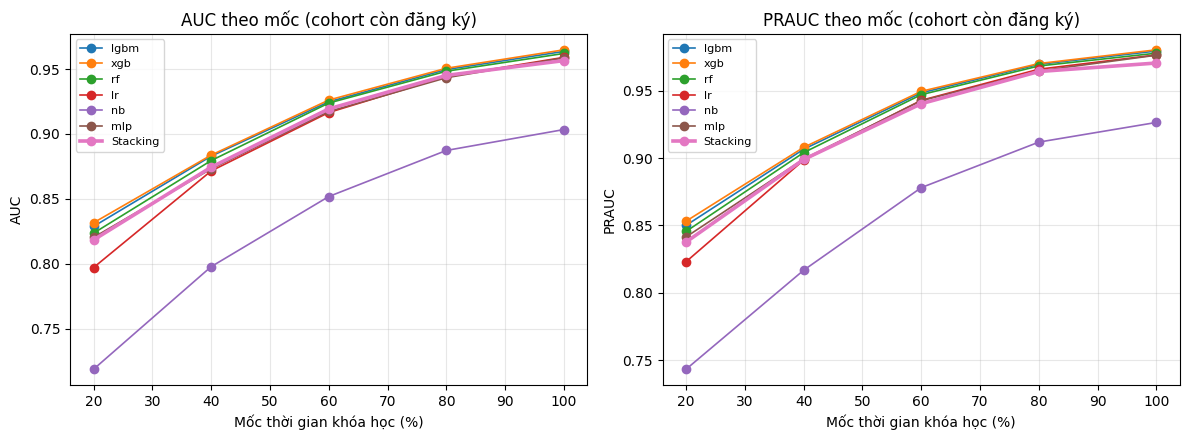

In [13]:
# 9. Hình: hiệu năng theo mốc
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
xs = [int(f*100) for f in MILESTONES]
for ax, metric in zip(axes, ['auc', 'prauc']):
    for name in zoo:
        ys = [results_df[(results_df.model==name)&(results_df.milestone==f'{int(f*100)}%')][metric].values[0]
              for f in MILESTONES]
        ax.plot(xs, ys, marker='o', linewidth=2.6 if name=='Stacking' else 1.2, label=name)
    ax.set_xlabel('Mốc thời gian khóa học (%)'); ax.set_ylabel(metric.upper())
    ax.set_title(f'{metric.upper()} theo mốc (cohort còn đăng ký)')
    ax.grid(alpha=.3); ax.legend(fontsize=8)
plt.tight_layout(); plt.savefig(f'{FIG_DIR}/fig_performance.png', dpi=150); plt.show()

## 10. XAI — chọn mô hình giải thích cho khớp

Nếu Wilcoxon ở cell 8 cho thấy Stacking **không** vượt trội, hãy đặt `EXPLAIN_MODEL = 'lgbm'`
và trình bày LightGBM làm mô hình chính của bài báo — khi đó TreeSHAP là chính xác (không xấp xỉ)
và giải thích khớp đúng mô hình được báo cáo.

Nếu Stacking **thực sự** vượt trội, đặt `EXPLAIN_MODEL = 'Stacking'`; notebook sẽ dùng
KernelSHAP (chậm hơn nhiều, có lấy mẫu nền).

In [14]:
# 10. RQ2 — SHAP theo mốc, tính trên ĐÚNG mô hình được báo cáo
EXPLAIN_MODEL = 'lgbm'      # 'lgbm' | 'Stacking'  <- đặt theo kết quả cell 8
SHAP_SAMPLE   = 3000        # số điểm để tính SHAP

def fit_explain_model(X, y):
    if EXPLAIN_MODEL == 'Stacking':
        return make_stacking().fit(X, y)
    return LGBMClassifier(n_estimators=N_TREES, learning_rate=0.05, num_leaves=31,
                          random_state=RANDOM_STATE, n_jobs=-1, verbose=-1).fit(X, y)

def compute_shap(model, X):
    Xs = X.sample(min(SHAP_SAMPLE, len(X)), random_state=RANDOM_STATE)
    if EXPLAIN_MODEL == 'Stacking':
        bg = shap.kmeans(X, 50)
        sv = shap.KernelExplainer(lambda z: model.predict_proba(z)[:, 1], bg).shap_values(Xs, nsamples=100)
        return pd.Series(np.abs(sv).mean(axis=0), index=X.columns), None
    ex = shap.TreeExplainer(model)
    sv = ex.shap_values(Xs)
    if isinstance(sv, list): sv = sv[1]
    if sv.ndim == 3: sv = sv[:, :, 1]
    return pd.Series(np.abs(sv).mean(axis=0), index=X.columns), (sv, Xs)

shap_by_ms, shap_raw = {}, {}
for f in MILESTONES:
    X, y, g, _ = datasets[f]
    mdl = fit_explain_model(X, y)
    s, raw = compute_shap(mdl, X)
    shap_by_ms[f] = s; shap_raw[f] = raw
    print(f'SHAP mốc {int(f*100)}% xong')

shap_mat = pd.DataFrame({f'{int(f*100)}%': shap_by_ms[f] for f in MILESTONES}).fillna(0)
shap_mat.to_csv(f'{OUT_DIR}/shap_trajectory_matrix.csv')
top_feats = shap_mat.mean(axis=1).sort_values(ascending=False).head(10).index
print('\nTop đặc trưng:', list(top_feats))

SHAP mốc 20% xong
SHAP mốc 40% xong
SHAP mốc 60% xong
SHAP mốc 80% xong
SHAP mốc 100% xong

Top đặc trưng: ['last_active_day', 'submission_rate', 'mean_score', 'days_since_last_active', 'weighted_avg_score', 'weight_done', 'second_half_ratio', 'highest_education', 'active_weeks', 'mean_days_early']


=== Bảng 3: Top-8 đặc trưng theo SHAP tại mỗi mốc ===
                       20%                     40%                     60%                     80%                    100%
Hạng 1          mean_score         submission_rate         submission_rate         last_active_day         last_active_day
Hạng 2   highest_education              mean_score         last_active_day              mean_score         submission_rate
Hạng 3               n_due         last_active_day  days_since_last_active  days_since_last_active              mean_score
Hạng 4     last_active_day             weight_done              mean_score             weight_done  days_since_last_active
Hạng 5     mean_days_early  days_since_last_active      weighted_avg_score      weighted_avg_score      weighted_avg_score
Hạng 6  weighted_avg_score      weighted_avg_score             weight_done         submission_rate                n_missed
Hạng 7        active_weeks       highest_education       second_half_ratio       seco

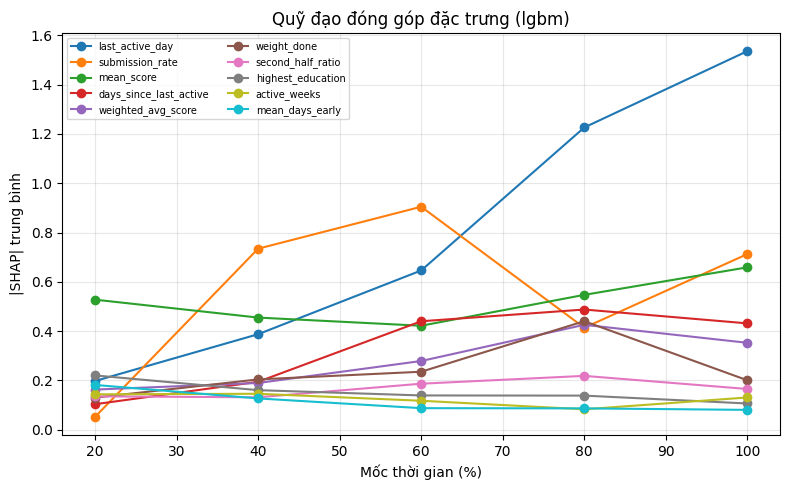

In [15]:
# 11. Bảng 3 + hình quỹ đạo đặc trưng
table3 = pd.DataFrame({f'{int(f*100)}%': shap_by_ms[f].sort_values(ascending=False).head(8).index
                       for f in MILESTONES})
table3.index = [f'Hạng {i+1}' for i in range(8)]
print('=== Bảng 3: Top-8 đặc trưng theo SHAP tại mỗi mốc ==='); print(table3.to_string())
table3.to_csv(f'{OUT_DIR}/table3_top_features.csv')

plt.figure(figsize=(8, 5))
for ft in top_feats:
    plt.plot(xs, [shap_mat.loc[ft, f'{int(f*100)}%'] for f in MILESTONES], marker='o', label=ft)
plt.xlabel('Mốc thời gian (%)'); plt.ylabel('|SHAP| trung bình')
plt.title(f'Quỹ đạo đóng góp đặc trưng ({EXPLAIN_MODEL})')
plt.legend(fontsize=7, ncol=2); plt.grid(alpha=.3); plt.tight_layout()
plt.savefig(f'{FIG_DIR}/fig_shap_trajectory.png', dpi=150); plt.show()

bootstrap mốc 20% xong
bootstrap mốc 40% xong
bootstrap mốc 60% xong
bootstrap mốc 80% xong
bootstrap mốc 100% xong

=== Quỹ đạo theo nhóm đặc trưng ===
                     20%    40%    60%    80%   100%
Hành vi tương tác  1.375  1.628  2.277  2.921  3.398
Kết quả đánh giá   1.742  2.305  2.485  2.493  2.856
Nhân khẩu học      0.653  0.380  0.363  0.355  0.325


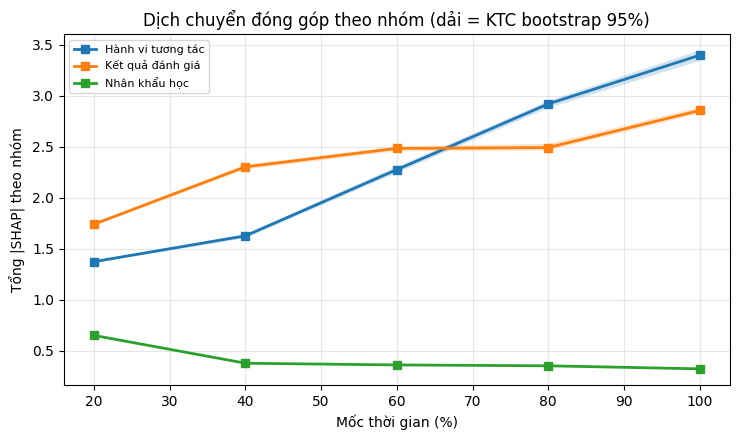

In [16]:
# 12. Quỹ đạo theo NHÓM + khoảng tin cậy bootstrap
# Không có CI thì không thể nói dịch chuyển là thật hay nhiễu.
def group_shap(s):
    return s.groupby([feat_group(i) for i in s.index]).sum()

boot = {g: {f: [] for f in MILESTONES} for g in ['Hành vi tương tác','Kết quả đánh giá','Nhân khẩu học']}
for f in MILESTONES:
    raw = shap_raw[f]
    if raw is None: continue
    sv, Xs = raw
    n = len(Xs)
    for b in range(N_BOOTSTRAP):
        idx = np.random.RandomState(b).choice(n, n, replace=True)
        s = pd.Series(np.abs(sv[idx]).mean(axis=0), index=Xs.columns)
        gs = group_shap(s)
        for gname in boot:
            boot[gname][f].append(gs.get(gname, 0.0))
    print(f'bootstrap mốc {int(f*100)}% xong')

group_df = pd.DataFrame({f'{int(f*100)}%': group_shap(shap_by_ms[f]) for f in MILESTONES}).fillna(0)
print('\n=== Quỹ đạo theo nhóm đặc trưng ==='); print(group_df.round(3).to_string())
group_df.to_csv(f'{OUT_DIR}/shap_group_trajectory.csv')

plt.figure(figsize=(7.5, 4.5))
for gname in group_df.index:
    vals = group_df.loc[gname].values
    plt.plot(xs, vals, marker='s', linewidth=2, label=gname)
    if boot[gname][MILESTONES[0]]:
        lo = [np.percentile(boot[gname][f], 2.5) for f in MILESTONES]
        hi = [np.percentile(boot[gname][f], 97.5) for f in MILESTONES]
        plt.fill_between(xs, lo, hi, alpha=.2)
plt.xlabel('Mốc thời gian (%)'); plt.ylabel('Tổng |SHAP| theo nhóm')
plt.title('Dịch chuyển đóng góp theo nhóm (dải = KTC bootstrap 95%)')
plt.legend(fontsize=8); plt.grid(alpha=.3); plt.tight_layout()
plt.savefig(f'{FIG_DIR}/fig_group_trajectory.png', dpi=150); plt.show()

In [17]:
# 13. RQ3 — Độ ổn định giải thích giữa các mốc
def top_k(s, k=10): return list(s.sort_values(ascending=False).head(k).index)
def feature_agreement(a, b, k=10): return len(set(top_k(a,k)) & set(top_k(b,k)))/k
def rank_agreement(a, b, k=10):
    ta, tb = top_k(a,k), top_k(b,k)
    return sum(1 for i in range(k) if ta[i]==tb[i])/k
def rank_corr(a, b):
    c = a.index.intersection(b.index); return spearmanr(a[c], b[c]).correlation

rows = []
for i in range(len(MILESTONES)-1):
    f1_, f2_ = MILESTONES[i], MILESTONES[i+1]
    a, b = shap_by_ms[f1_], shap_by_ms[f2_]
    rows.append({'pair': f'{int(f1_*100)}%->{int(f2_*100)}%',
                 'FeatureAgreement': round(feature_agreement(a,b),3),
                 'RankAgreement': round(rank_agreement(a,b),3),
                 'RankCorrelation': round(rank_corr(a,b),3)})
# so sánh xa nhất: 20% vs 100%
a, b = shap_by_ms[0.2], shap_by_ms[1.0]
rows.append({'pair': '20%->100%', 'FeatureAgreement': round(feature_agreement(a,b),3),
             'RankAgreement': round(rank_agreement(a,b),3), 'RankCorrelation': round(rank_corr(a,b),3)})
table4 = pd.DataFrame(rows)
print('=== Bảng 4: Độ ổn định giải thích ==='); print(table4.to_string(index=False))
table4.to_csv(f'{OUT_DIR}/table4_stability.csv', index=False)

=== Bảng 4: Độ ổn định giải thích ===
     pair  FeatureAgreement  RankAgreement  RankCorrelation
 20%->40%               0.8            0.1            0.862
 40%->60%               0.9            0.1            0.879
 60%->80%               0.8            0.4            0.870
80%->100%               0.7            0.2            0.898
20%->100%               0.7            0.1            0.689


## 14. Kiểm định độ trung thực (faithfulness) của giải thích

Đây là phần biến *"SHAP nói X quan trọng"* thành *"X thực sự quan trọng"*.
Cách làm: bỏ dần top-k đặc trưng theo SHAP rồi đo AUC tụt bao nhiêu, so với bỏ k đặc trưng **ngẫu nhiên**.
Nếu đường "bỏ top-k" tụt mạnh hơn hẳn đường ngẫu nhiên → giải thích là trung thực.

Faithfulness tại mốc 20% (mốc quan trọng nhất của bài báo):
  k=0 xong
  k=1 xong
  k=2 xong
  k=3 xong
  k=5 xong
  k=8 xong
  k=12 xong
  k=20 xong
mode  random    shap
k                   
0     0.8282  0.8282
1     0.8282  0.8287
2     0.8282  0.8253
3     0.8285  0.8246
5     0.8271  0.8242
8     0.8261  0.8223
12    0.8279  0.8147
20    0.8240  0.8102


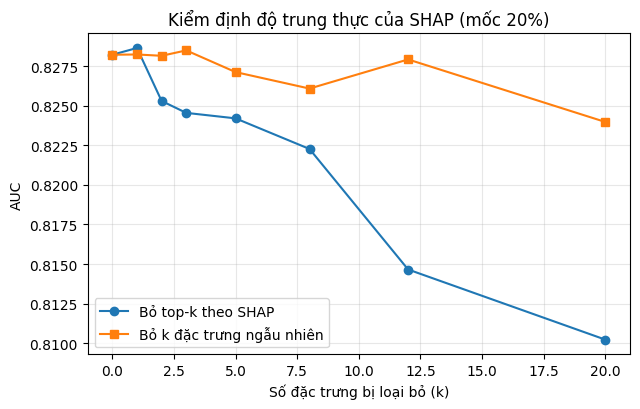

In [18]:
# 14. Faithfulness: deletion curve
def deletion_curve(f, ks=(0,1,2,3,5,8,12,20)):
    X, y, g, _ = datasets[f]
    order = shap_by_ms[f].sort_values(ascending=False).index.tolist()
    cv = StratifiedGroupKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
    rng = np.random.RandomState(0)
    out = []
    for k in ks:
        for mode in ['shap', 'random']:
            drop = order[:k] if mode=='shap' else list(rng.choice(X.columns, k, replace=False)) if k else []
            Xk = X.drop(columns=drop)
            aucs = []
            for tr, te in cv.split(Xk, y, groups=g):
                m = LGBMClassifier(n_estimators=150, learning_rate=.05, random_state=RANDOM_STATE,
                                   n_jobs=-1, verbose=-1).fit(Xk.iloc[tr], y[tr])
                aucs.append(roc_auc_score(y[te], m.predict_proba(Xk.iloc[te])[:,1]))
            out.append({'k': k, 'mode': mode, 'auc': np.mean(aucs)})
        print(f'  k={k} xong')
    return pd.DataFrame(out)

print('Faithfulness tại mốc 20% (mốc quan trọng nhất của bài báo):')
faith = deletion_curve(0.2)
piv = faith.pivot(index='k', columns='mode', values='auc')
print(piv.round(4).to_string())
piv.to_csv(f'{OUT_DIR}/table5_faithfulness.csv')

plt.figure(figsize=(6.5, 4.2))
plt.plot(piv.index, piv['shap'], marker='o', label='Bỏ top-k theo SHAP')
plt.plot(piv.index, piv['random'], marker='s', label='Bỏ k đặc trưng ngẫu nhiên')
plt.xlabel('Số đặc trưng bị loại bỏ (k)'); plt.ylabel('AUC')
plt.title('Kiểm định độ trung thực của SHAP (mốc 20%)')
plt.legend(); plt.grid(alpha=.3); plt.tight_layout()
plt.savefig(f'{FIG_DIR}/fig_faithfulness.png', dpi=150); plt.show()

## 15. RQ3 — Kiểm chứng khái quát: Leave-One-Module-Out

Thay cho bộ *Engagement* mô phỏng. Ưu điểm:
- Dữ liệu **thật**, giữ nguyên **trục thời gian** → kiểm chứng được cả RQ2 lẫn RQ3
- Trả lời trực tiếp hạn chế "một khóa học / một cơ sở" mà nhiều nghiên cứu liên quan đều nêu
- Cho biết: quỹ đạo đặc trưng có **giống nhau giữa các môn học** không?

Tỷ lệ đạt rất khác nhau giữa các module (AAA 71% vs CCC 37.8%) → đây là bài kiểm tra khái quát thật sự khắt khe.

In [19]:
# 15. Leave-One-Module-Out tại mốc 20%
LOMO_MS = 0.2
X, y, g, info = datasets[LOMO_MS]
modules = sorted(info['code_module'].unique())

rows, shap_per_module = [], {}
for mod in modules:
    te_mask = (info['code_module'] == mod).values
    Xtr, Xte, ytr, yte = X[~te_mask], X[te_mask], y[~te_mask], y[te_mask]
    if len(np.unique(yte)) < 2: continue
    m = LGBMClassifier(n_estimators=N_TREES, learning_rate=.05, random_state=RANDOM_STATE,
                       n_jobs=-1, verbose=-1).fit(Xtr, ytr)
    pr = m.predict_proba(Xte)[:,1]
    rows.append({'module_test': mod, 'n_test': len(Xte), 'tỷ lệ đạt': round(yte.mean(),3),
                 'AUC': round(roc_auc_score(yte, pr),4),
                 'PR-AUC': round(average_precision_score(yte, pr),4),
                 'F1': round(f1_score(yte, m.predict(Xte)),4)})
    # SHAP riêng cho từng module -> so quỹ đạo giữa các môn
    mm = LGBMClassifier(n_estimators=N_TREES, learning_rate=.05, random_state=RANDOM_STATE,
                        n_jobs=-1, verbose=-1).fit(Xte, yte) if len(Xte) > 300 else None
    if mm is not None:
        sv = shap.TreeExplainer(mm).shap_values(Xte.sample(min(1000,len(Xte)), random_state=1))
        if isinstance(sv, list): sv = sv[1]
        if sv.ndim == 3: sv = sv[:, :, 1]
        shap_per_module[mod] = pd.Series(np.abs(sv).mean(axis=0), index=X.columns)
    print(f'  {mod} xong')

lomo = pd.DataFrame(rows)
print('\n=== Bảng 2: Leave-One-Module-Out (mốc 20%) ==='); print(lomo.to_string(index=False))
print(f'\nAUC trung bình: {lomo["AUC"].mean():.4f} ± {lomo["AUC"].std():.4f}')
lomo.to_csv(f'{OUT_DIR}/table2_lomo.csv', index=False)

  AAA xong
  BBB xong
  CCC xong
  DDD xong
  EEE xong
  FFF xong
  GGG xong

=== Bảng 2: Leave-One-Module-Out (mốc 20%) ===
module_test  n_test  tỷ lệ đạt    AUC  PR-AUC     F1
        AAA     708      0.750 0.7834  0.9089 0.7522
        BBB    6295      0.596 0.7706  0.8103 0.6392
        CCC    3265      0.514 0.8319  0.8185 0.7031
        DDD    5116      0.510 0.8246  0.8122 0.7640
        EEE    2498      0.661 0.8297  0.8807 0.8395
        FFF    6403      0.570 0.8238  0.8331 0.8016
        GGG    2408      0.629 0.6845  0.7717 0.0710

AUC trung bình: 0.7926 ± 0.0535


=== Tỷ trọng đóng góp theo nhóm, từng module (mốc 20%) ===
                     AAA    BBB    CCC    DDD    EEE    FFF    GGG
Hành vi tương tác  0.548  0.386  0.422  0.454  0.583  0.443  0.679
Kết quả đánh giá   0.326  0.420  0.433  0.382  0.286  0.407  0.070
Nhân khẩu học      0.125  0.194  0.145  0.165  0.132  0.151  0.251

=== Nhất quán giải thích giữa các module ===
cặp module  FeatureAgreement  RankCorrelation
AAA vs BBB               0.4            0.590
AAA vs CCC               0.4            0.681
AAA vs DDD               0.3            0.633
AAA vs EEE               0.3            0.558
AAA vs FFF               0.3            0.408
AAA vs GGG               0.3            0.521
BBB vs CCC               0.5            0.769
BBB vs DDD               0.4            0.663
BBB vs EEE               0.4            0.607
BBB vs FFF               0.6            0.549
BBB vs GGG               0.4            0.543
CCC vs DDD               0.6            0.700
CCC vs EEE               0.4 

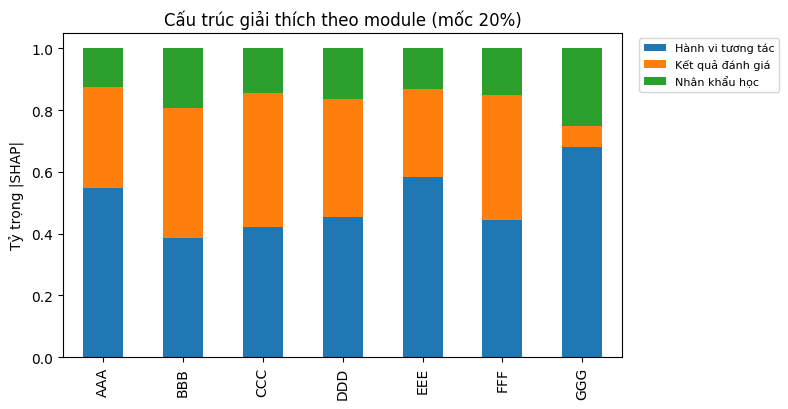

In [20]:
# 16. Giải thích có nhất quán GIỮA CÁC MÔN HỌC không? (RQ3)
if len(shap_per_module) >= 2:
    gm = pd.DataFrame({m: group_shap(s) for m, s in shap_per_module.items()}).fillna(0)
    # chuẩn hóa theo cột để so tỷ trọng
    gm_norm = gm / gm.sum(axis=0)
    print('=== Tỷ trọng đóng góp theo nhóm, từng module (mốc 20%) ===')
    print(gm_norm.round(3).to_string())
    gm_norm.to_csv(f'{OUT_DIR}/table6_group_by_module.csv')

    mods = list(shap_per_module)
    cons = [{'cặp module': f'{a} vs {b}',
             'FeatureAgreement': round(feature_agreement(shap_per_module[a], shap_per_module[b]),3),
             'RankCorrelation': round(rank_corr(shap_per_module[a], shap_per_module[b]),3)}
            for i,a in enumerate(mods) for b in mods[i+1:]]
    cons = pd.DataFrame(cons)
    print('\n=== Nhất quán giải thích giữa các module ===')
    print(cons.to_string(index=False))
    print(f'\nRankCorrelation trung bình: {cons["RankCorrelation"].mean():.3f}')
    cons.to_csv(f'{OUT_DIR}/table7_cross_module_consistency.csv', index=False)

    gm_norm.T.plot(kind='bar', stacked=True, figsize=(8,4.2))
    plt.ylabel('Tỷ trọng |SHAP|'); plt.title('Cấu trúc giải thích theo module (mốc 20%)')
    plt.legend(fontsize=8, bbox_to_anchor=(1.02,1)); plt.tight_layout()
    plt.savefig(f'{FIG_DIR}/fig_group_by_module.png', dpi=150); plt.show()

In [21]:
# 17. RQ4 — Giải thích cục bộ cho sinh viên nguy cơ tại mốc 20%
from lime.lime_tabular import LimeTabularExplainer
X, y, g, info = datasets[0.2]
clf = LGBMClassifier(n_estimators=N_TREES, learning_rate=.05, random_state=RANDOM_STATE,
                     n_jobs=-1, verbose=-1).fit(X, y)
risk = clf.predict_proba(X)[:, 0]
# chọn ca nguy cơ cao NHƯNG vẫn còn đang học (đã lọc cohort nên mọi ca đều hợp lệ)
idx = int(np.argsort(-risk)[0])
print(f'Sinh viên {info.iloc[idx].to_dict()} | P(nguy cơ)={risk[idx]:.3f} | thực tế={"đạt" if y[idx] else "không đạt"}')

sv = shap.TreeExplainer(clf).shap_values(X.iloc[[idx]])
if isinstance(sv, list): sv = sv[1]
if sv.ndim == 3: sv = sv[:, :, 1]
local = pd.Series(sv[0], index=X.columns).sort_values(key=np.abs, ascending=False).head(10)
print('\nSHAP cục bộ (âm = đẩy về phía nguy cơ):'); print(local.round(4).to_string())

lx = LimeTabularExplainer(X.values, feature_names=list(X.columns),
                          class_names=['nguy_cơ','đạt'], mode='classification')
e = lx.explain_instance(X.iloc[idx].values, clf.predict_proba, num_features=10)
print('\nLIME:')
for k, v in e.as_list(): print(f'  {k}: {v:+.3f}')

Sinh viên {'id_student': 547302, 'code_module': 'FFF', 'code_presentation': '2013B'} | P(nguy cơ)=0.996 | thực tế=không đạt

SHAP cục bộ (âm = đẩy về phía nguy cơ):
mean_score           -0.8246
n_missed             -0.7696
last_score           -0.4465
weighted_avg_score   -0.4292
second_half_ratio    -0.3859
clk_page             -0.3418
region_Wales         -0.3297
pre_course_clicks    -0.3110
n_due                -0.2738
clk_ouwiki           -0.2063

LIME:
  mean_score <= 56.00: -0.236
  clk_repeatactivity <= 0.00: +0.124
  clk_page > 0.00: -0.112
  highest_education <= 1.00: -0.112
  weighted_avg_score <= 50.00: -0.111
  n_missed > 1.00: -0.101
  last_active_day <= 44.00: -0.079
  days_since_last_active > 5.00: -0.075
  mean_days_early <= 0.00: -0.073
  second_half_ratio <= 0.25: -0.071


In [22]:
# 18. Đóng gói kết quả
import shutil
shutil.make_archive(f'{OUT_DIR}/paper_outputs', 'zip', OUT_DIR)
print('Các file kết quả:')
for f in sorted(os.listdir(OUT_DIR)): print(' ', f)
print('\nHình:')
for f in sorted(os.listdir(FIG_DIR)): print(' ', f)

Các file kết quả:
  figs
  paper_outputs.zip
  results_by_milestone.csv
  shap_group_trajectory.csv
  shap_trajectory_matrix.csv
  table0_cohort.csv
  table1_auc.csv
  table1_f1.csv
  table1_prauc.csv
  table2_lomo.csv
  table3_top_features.csv
  table4_stability.csv
  table5_faithfulness.csv
  table6_group_by_module.csv
  table7_cross_module_consistency.csv
  table_stats.csv

Hình:
  fig_faithfulness.png
  fig_group_by_module.png
  fig_group_trajectory.png
  fig_performance.png
  fig_shap_trajectory.png


## Ghi chú khi viết bài báo

1. **F1 không so sánh được với bản cũ** — cohort và tỷ lệ lớp đã đổi (47.2% → 57.6% ở mốc 20%). Dùng AUC/PR-AUC.
2. **Mô tả cohort rõ ràng** trong Mục Data: "tại mốc *m*, phân tích giới hạn ở sinh viên còn đăng ký tại thời điểm *m*"
   và nêu con số ở `table0_cohort.csv`. Đây là thiết kế *early-warning* đúng nghĩa: *"trong số sinh viên còn đang học
   ở tuần X, ai có nguy cơ?"*
3. **Nêu rõ đã loại Exam** khỏi đặc trưng và giải thích lý do (weight=100, tách bạch nhãn).
4. **Cỡ cohort giảm dần theo mốc** → nêu trong Limitations rằng chỉ số giữa các mốc tính trên các quần thể khác nhau
   (khác biệt này là bản chất của bài toán, không phải lỗi).
5. **Nếu Stacking không thắng** (rất có thể), dùng framing: *stacking đạt hiệu năng ngang mô hình đơn tốt nhất tại mọi
   mốc mà không cần chọn mô hình thủ công theo từng giai đoạn* — đó là lập luận về tính ổn định, và phải kèm bằng chứng
   rằng mô hình tốt nhất **đổi** theo mốc (xem `table1_auc.csv`).
6. **Mốc 100% mang tính vòng lặp một phần** — điểm TMA/CMA góp phần cấu thành `final_result`. Trọng tâm khoa học nên
   đặt ở mốc **20–40%**.
7. Mọi tuyên bố về khoảng trống nghiên cứu phải **trích dẫn nguồn**; tránh "chưa ai làm" / "đầu tiên".
